# Supplementary Fig. 29 — false-positive rate of the longitudinal *phased* mCA caller (simulated null data)

Four-panel evaluation of the false-positive rate (FPR) of the TETRIS-seq longitudinal **phased** mCA caller,
using a **within-family null design**: phasing is derived from the index sample at a given cell fraction and
applied to the *unmodified* control sample from the same individual (true cell fraction 0%); any significant
detection is a false positive. Significance is a one-sided t-test at α = 0.05. **n = 2017 null tests.**

- **a** distribution of one-sided p-values across all null tests (uniform under the null)
- **b** FPR by index-sample cell fraction (25 / 50 / 75 / 100%)
- **c** FPR by mCA type (CN-LOH, gain, loss)
- **d** FPR by mCA size (≥5 Mb; 2 Mb and 3 Mb excluded — below the unphased caller's range)

Numbers above each bar are false positives / total null tests; the dashed line marks the nominal 5% level.

## Data availability
Self-contained: one **simulated** within-family null table,
`Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/Within_family_fpr_results.csv`. Written by `Supplementary_Fig_28-29-mCA_phased_caller_benchmarking_on_simulated_samples.ipynb`.

## 1. Imports, colours, constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33); c2 = (1.00, 0.23, 0.19)
c3 = (1.00, 0.58, 0.00); c4 = (1.00, 0.80, 0.00)
c5 = (0.30, 0.85, 0.39); c6 = (0.35, 0.78, 0.98)
c7 = (0.20, 0.67, 0.86); c8 = (0.00, 0.48, 1.00)
c9 = (0.35, 0.34, 0.84); c10 = (0.00, 0.31, 0.57)

orange1='#feedde'; orange2='#fdbe85'; orange3='#fd8d3c'; orange4='#e6550d'; orange5='#a63603'
blue1='#eff3ff'; blue2='#bdd7e7'; blue3='#6baed6'; blue4='#3182bd'; blue5='#08519c'
green1='#edf8e9'; green2='#bae4b3'; green3='#74c476'; green4='#31a354'; green5='#006d2c'
grey1='#f7f7f7'; grey2='#cccccc'; grey3='#969696'; grey4='#636363'; grey5='#252525'
purple1='#f2f0f7'; purple2='#cbc9e2'; purple3='#9e9ac8'; purple4='#756bb1'; purple5='#54278f'
red1='#fee5d9'; red2='#fcae91'; red3='#fb6a4a'; red4='#de2d26'; red5='#a50f15'

In [3]:
CHROM_ORDER = [f'chr{i}' for i in range(1, 23)] + ['chrX']
CHROM_LABELS = [str(i) for i in range(1, 23)] + ['X']

# Size categories
ALL_SIZES = ['2Mb', '3Mb', '5Mb', '10Mb', '20Mb', 'WholeArm']
SIZES_5PLUS = ['5Mb', '10Mb', '20Mb', 'WholeArm']

# Shared styling
EVENT_COLORS = {'CN-LOH': '#2E86AB', 'GAIN': '#F77F00', 'LOSS': '#06A77D'}
SIZE_COLORS = {
    '2Mb': '#E63946', '3Mb': '#F77F00', '5Mb': '#FCBF49',
    '10Mb': '#06A77D', '20Mb': '#2E86AB', 'WholeArm': '#7B2D8E'
}
GEOM_COLORS = {'Interstitial': '#2E86AB', 'Telomeric': '#F77F00', 'Whole_Arm': '#06A77D'}


## 2. Load the within-family null results

In [4]:
def load_fpr_data(fpr_csv, ref_cf=None):
    """Load FPR results, filter to tested rows and optional ref CF."""
    df = pd.read_csv(fpr_csv)
    df = df[df['status'] == 'tested'].copy()
    if ref_cf is not None and 'ref_cf' in df.columns:
        df = df[np.isclose(df['ref_cf'], ref_cf)]
    return df

In [5]:
# Within-family null results for the longitudinal PHASED caller (simulated; no individual-level data).
# Phasing derived from the index sample is applied to the UNMODIFIED control (0% cell fraction);
# any significant detection is a false positive. n = 2017 null tests.
FPR_CSV = 'Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/Within_family_fpr_results.csv'
fpr_df = load_fpr_data(FPR_CSV)
print(f'null tests: {len(fpr_df)}  |  false positives: {int(fpr_df["significant"].sum())} '
      f'({fpr_df["significant"].mean()*100:.2f}%)')

null tests: 2017  |  false positives: 128 (6.35%)


## 3. The 4-panel FPR summary (a–d)

In [6]:
def plot_fpr_summary(fpr_df, ref_pct):
    """
    4-panel single-row FPR summary:
      a. P-value distribution (uniform under null)
      b. FPR by index sample CF
      c. FPR by event type
      d. FPR by event size (≥5 Mb only)
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('False Positive Rate (Within-Family Null, phased caller)',
                 fontsize=14, fontweight='bold', y=1.02)
    alpha = 0.05

    # ── Panel a: P-value distribution ──
    ax = axes[0]
    pvals = fpr_df['p_onesided'].dropna()
    if len(pvals) > 0:
        ax.hist(pvals, bins=20, range=(0, 1), color=blue3, alpha=0.7,
                edgecolor='white', density=True, label=f'N = {len(pvals)}')
        ax.axhline(1.0, color='grey', linestyle='--', alpha=0.7,
                   label='Uniform (expected)')
        ax.axvline(alpha, color=red4, linestyle='-', linewidth=1.5, alpha=0.8,
                   label=f'\u03b1 = {alpha}')
    ax.set_xlabel('p-value (one-sided)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('P-value Distribution (null regions)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

    # ── Panel b: FPR by index sample CF ──
    ax = axes[1]
    bar_vals = []
    if 'ref_cf' in fpr_df.columns:
        ref_cfs = sorted(fpr_df['ref_cf'].unique())
        bar_labels = []
        for rcf in ref_cfs:
            rcf_data = fpr_df[np.isclose(fpr_df['ref_cf'], rcf)]
            n = len(rcf_data)
            n_fp = int(rcf_data['significant'].sum())
            bar_vals.append(n_fp / n * 100 if n > 0 else 0)
            bar_labels.append(f'{rcf*100:.0f}%')
        x_pos = range(len(ref_cfs))
        ax.bar(x_pos, bar_vals, color=blue4, edgecolor='white')
        ax.axhline(alpha * 100, color='grey', linestyle='--', alpha=0.7,
                   label=f'\u03b1 = {alpha*100:.0f}%')
        for i, (rcf, val) in enumerate(zip(ref_cfs, bar_vals)):
            rcf_data = fpr_df[np.isclose(fpr_df['ref_cf'], rcf)]
            n_fp = int(rcf_data['significant'].sum())
            ax.text(i, val + 0.3, f'{n_fp}/{len(rcf_data)}\n({val:.1f}%)',
                    ha='center', fontsize=8, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(bar_labels, fontsize=10)
        ax.set_xlabel('Index Sample CF', fontsize=11)
        ax.set_ylim(0, max(max(bar_vals) * 2, alpha * 100 * 3) if bar_vals else 15)
    else:
        ax.text(0.5, 0.5, 'ref_cf not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='grey')
        ax.set_ylim(0, 15)
    ax.set_ylabel('FPR (%)', fontsize=11)
    ax.set_title('FPR by Index Sample CF', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

    # ── Panel c: FPR by event type ──
    ax = axes[2]
    events = ['CN-LOH', 'GAIN', 'LOSS']
    bar_vals = []
    for evt in events:
        ed = fpr_df[fpr_df['event'] == evt]
        bar_vals.append(ed['significant'].sum() / len(ed) * 100 if len(ed) > 0 else 0)
    bar_colors = [EVENT_COLORS.get(e, grey4) for e in events]
    ax.bar(range(len(events)), bar_vals, color=bar_colors, edgecolor='white')
    ax.axhline(alpha * 100, color='grey', linestyle='--', alpha=0.7,
               label=f'\u03b1 = {alpha*100:.0f}%')
    for i, (evt, val) in enumerate(zip(events, bar_vals)):
        ed = fpr_df[fpr_df['event'] == evt]
        n_fp = int(ed['significant'].sum())
        ax.text(i, val + 0.3, f'{n_fp}/{len(ed)}\n({val:.1f}%)',
                ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(events)))
    ax.set_xticklabels(events, fontsize=11)
    ax.set_ylabel('FPR (%)', fontsize=11)
    ax.set_title('FPR by Event Type', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(max(bar_vals) * 2, alpha * 100 * 3) if bar_vals else 15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

    # ── Panel d: FPR by event size (≥5 Mb) ──
    ax = axes[3]
    sizes_present = [s for s in ALL_SIZES if s in fpr_df['size'].unique() and s not in ('2Mb', '3Mb')]
    bar_vals = []
    for sz in sizes_present:
        sd = fpr_df[fpr_df['size'] == sz]
        bar_vals.append(sd['significant'].sum() / len(sd) * 100 if len(sd) > 0 else 0)
    sz_colors = [SIZE_COLORS.get(s, grey4) for s in sizes_present]
    ax.bar(range(len(sizes_present)), bar_vals, color=sz_colors, edgecolor='white')
    ax.axhline(alpha * 100, color='grey', linestyle='--', alpha=0.7,
               label=f'\u03b1 = {alpha*100:.0f}%')
    for i, (sz, val) in enumerate(zip(sizes_present, bar_vals)):
        sd = fpr_df[fpr_df['size'] == sz]
        n_fp = int(sd['significant'].sum())
        ax.text(i, val + 0.3, f'{n_fp}/{len(sd)}',
                ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(sizes_present)))
    ax.set_xticklabels(sizes_present, fontsize=10)
    ax.set_ylabel('FPR (%)', fontsize=11)
    ax.set_title('FPR by Event Size', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(max(bar_vals) * 2, alpha * 100 * 3) if bar_vals else 15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

    for a in axes:
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        for sp in ['bottom', 'left']:
            a.spines[sp].set_linewidth(1.5)
            a.spines[sp].set_color(grey3)
        a.xaxis.set_tick_params(width=1, color=grey3, length=6)
        a.yaxis.set_tick_params(width=1, color=grey3, length=6)

    plt.tight_layout()
    plt.show()

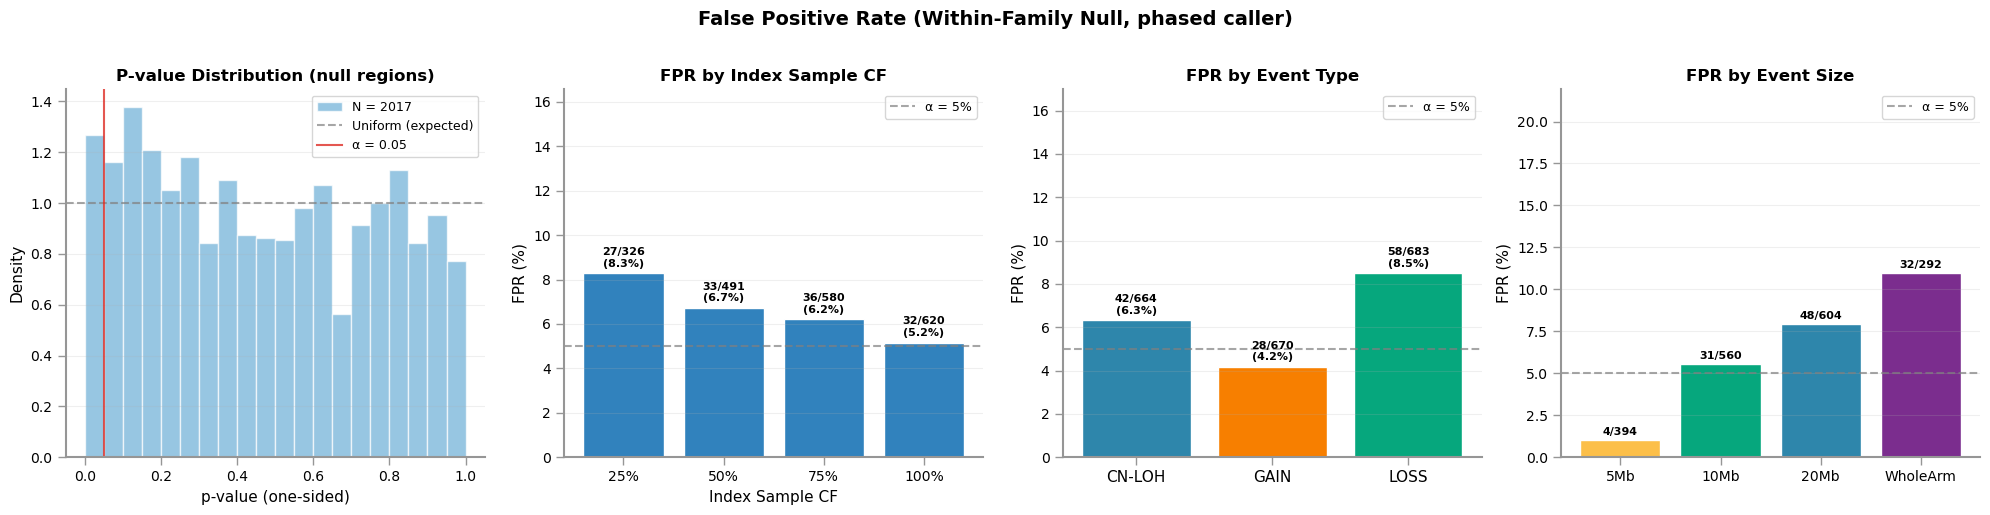

In [7]:
plot_fpr_summary(fpr_df, '75')